# 02 — Preprocessing and Morphological Segmentation

This notebook develops and visualises the preprocessing pipeline that isolates stamp ink pixels from the rest of the document. It works on a **single sample image** to allow step-by-step inspection of each stage.

**Input:** One raw scanned document image (`.png`)  
**Output:** `filtered_mask` — a binary mask containing only stamp-region pixels, ready for geometric localisation

---
## Pipeline Overview
```
RGB image → Resize → HSV conversion → Colour thresholding → 
Morphological closing → Morphological opening → Connected component filtering
```

---
## Contents
1. Imports
2. Load sample image
3. Resize for display
4. Visualise original image
5. Convert to HSV colour space
6. Visualise HSV channels
7. Apply HSV colour threshold (blue/violet range)
8. Visualise initial mask
9. Morphological closing — fill ink gaps
10. Morphological opening — remove text noise
11. Connected component filtering — remove non-circular blobs
12. Final comparison


## 1. Imports

In [52]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Sample Image

Scans `IMAGE_PATH` recursively for `.png` files and selects one as a test case (`all_images[2]`).

> ⚠️ Update `IMAGE_PATH` to your local `final_dataset/` directory.


In [53]:
from pathlib import Path

# Change this to one actual image path from your dataset
IMAGE_PATH = Path(
    r"D:\OneDrive - engug.ruh.ac.lk\2. Semester 7\EC7205 - IMAGE PROCESSING AND COMPUTER VISION\1. Project\final_dataset\final_dataset"
)

# Find one PNG image automatically
all_images = list(IMAGE_PATH.rglob("*.png"))

print("Total PNG images found:", len(all_images))

sample_image_path = all_images[2]

print("Using image:")
print(sample_image_path)

image_bgr = cv2.imread(str(sample_image_path))

print("Image loaded:", image_bgr is not None)

if image_bgr is not None:
    print("Original shape:", image_bgr.shape)

Total PNG images found: 543
Using image:
D:\OneDrive - engug.ruh.ac.lk\2. Semester 7\EC7205 - IMAGE PROCESSING AND COMPUTER VISION\1. Project\final_dataset\final_dataset\class_0_genuine\stamp_A\Gen_A_300dpi_003.png
Image loaded: True
Original shape: (3506, 2481, 3)


## 3. Resize for Display

Resizes the image to a fixed display width of **900 px** (preserving aspect ratio). All subsequent processing in this notebook operates on the resized image for faster iteration. In the final pipeline (notebook 04), the ROI is cropped from the original full-resolution image.


In [54]:
DISPLAY_WIDTH = 900

h, w = image_bgr.shape[:2]

scale = DISPLAY_WIDTH / w
new_h = int(h * scale)

image_resized = cv2.resize(
    image_bgr,
    (DISPLAY_WIDTH, new_h)
)

print("Resized shape:", image_resized.shape)

Resized shape: (1271, 900, 3)


## 4. Visualise Original Image

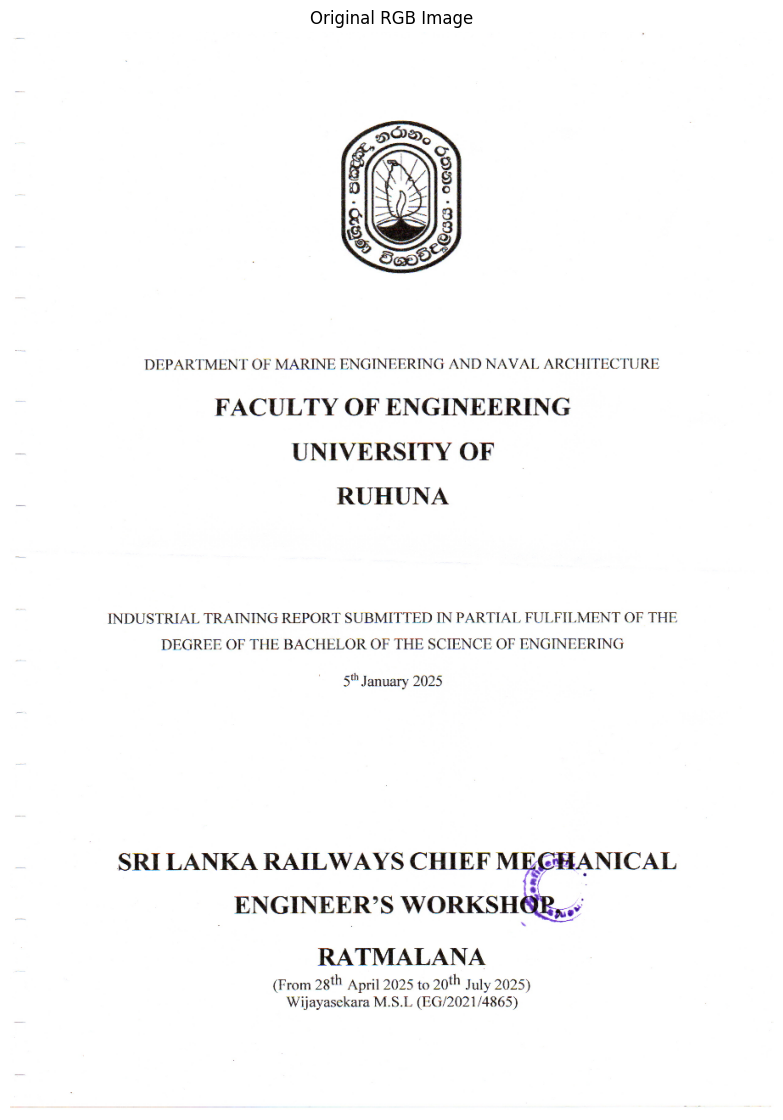

In [55]:
image_rgb = cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 14))
plt.imshow(image_rgb)
plt.title("Original RGB Image")
plt.axis("off")
plt.show()


## 5. Convert to HSV Colour Space

Converts the BGR image to HSV using `cv2.COLOR_BGR2HSV`.

**Why HSV?**  
The Hue channel directly encodes colour independent of brightness. Blue/violet stamp ink occupies a narrow, predictable hue range (~95–165 in OpenCV's 0–179 scale), while black document text has near-zero saturation — making the two easy to separate in HSV but not in RGB.


In [56]:
image_hsv = cv2.cvtColor(image_resized, cv2.COLOR_BGR2HSV)

print("HSV shape:", image_hsv.shape)

HSV shape: (1271, 900, 3)


## Visualise HSV Channels

The HSV image is split into its three individual channels and displayed separately. This helps understand what information each channel carries before applying the threshold.

- **Hue:** displayed with the HSV colourmap — stamp ink appears as a distinct colour band in the blue/violet range while black text appears dark
- **Saturation:** displayed in grayscale — white paper appears black (zero saturation), black text appears dark grey (very low saturation), and the stamp ink appears as the brightest region due to its vivid blue/violet colour (high saturation)
- **Value:** displayed in grayscale — white paper appears bright (high brightness), black text appears dark (low brightness), and the stamp ink is not clearly distinguishable since its brightness is similar to the surrounding paper — confirming that Value alone is not useful for separating the stamp from the background

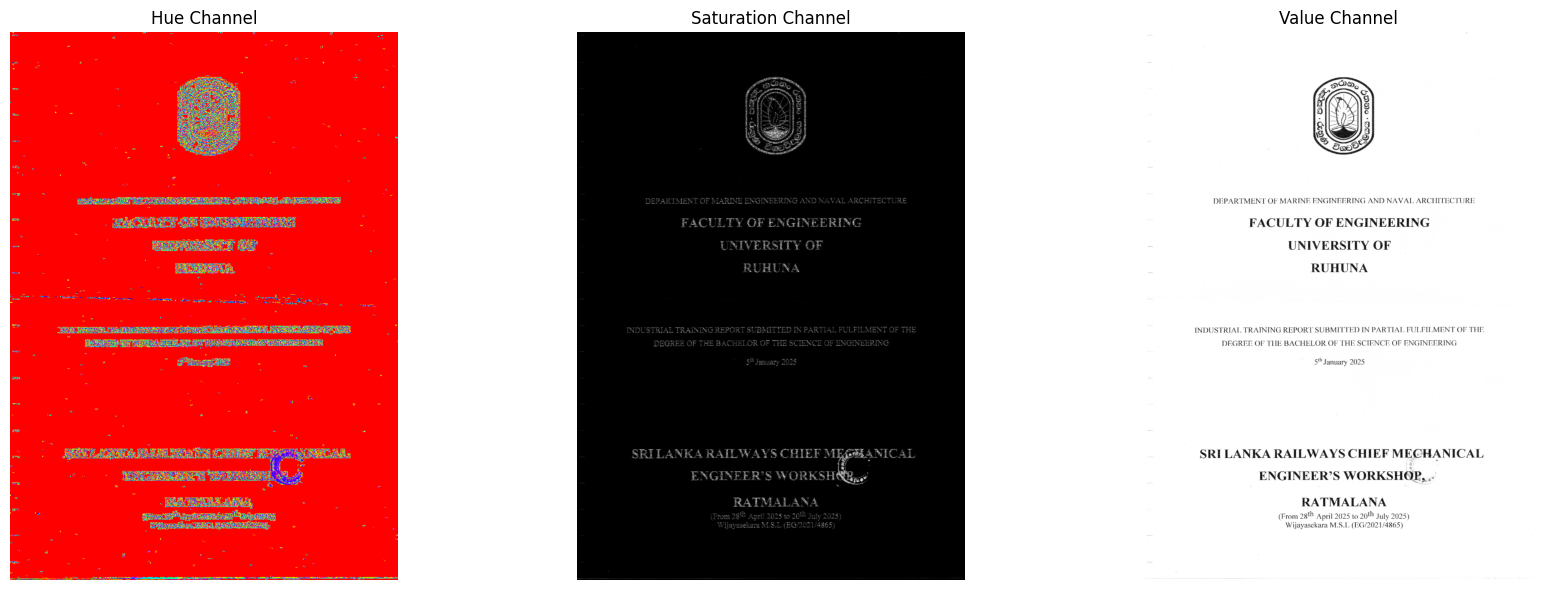

In [57]:
h_channel = image_hsv[:, :, 0]
s_channel = image_hsv[:, :, 1]
v_channel = image_hsv[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(h_channel, cmap="hsv")
axes[0].set_title("Hue Channel")
axes[0].axis("off")

axes[1].imshow(s_channel, cmap="gray")
axes[1].set_title("Saturation Channel")
axes[1].axis("off")

axes[2].imshow(v_channel, cmap="gray")
axes[2].set_title("Value Channel")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 7. Apply HSV Colour Threshold

Creates a binary mask using `cv2.inRange` with the blue/violet hue range:

| Parameter | Value |
|---|---|
| Hue range | 95 – 165 |
| Saturation range | 60 – 255 |
| Value range | 40 – 255 |

Pixels within this range are set to 255 (white); all others to 0 (black).


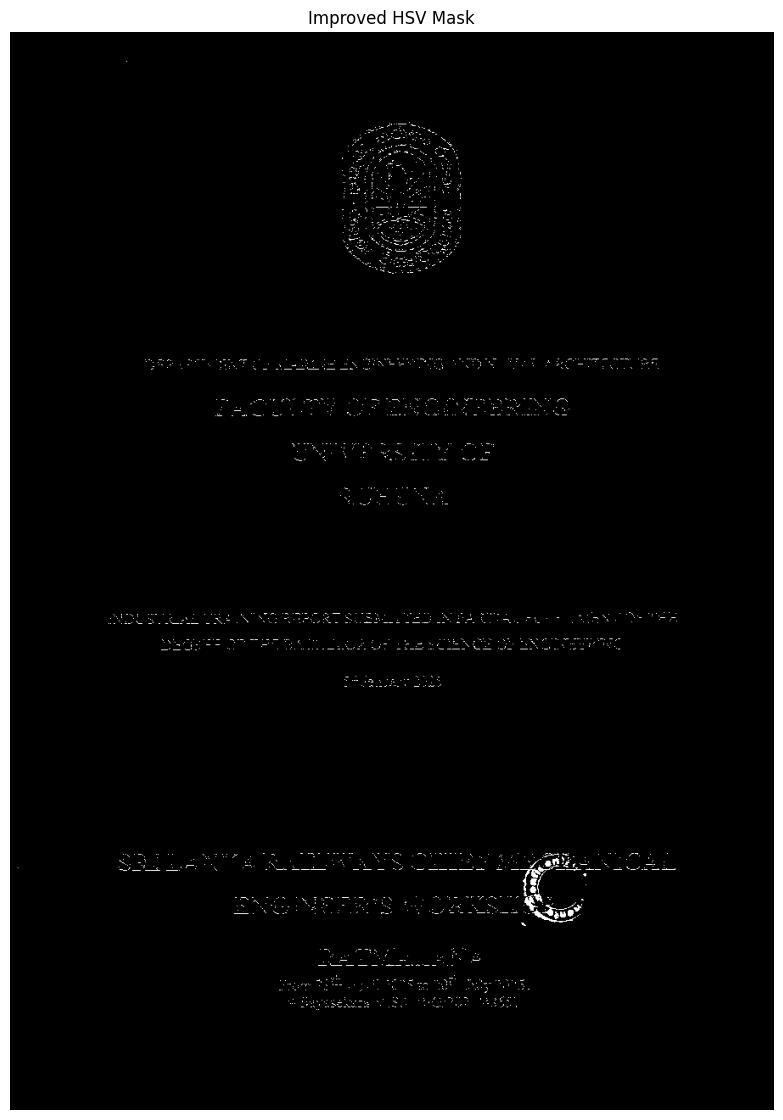

In [58]:
# Improved blue/violet threshold
lower_stamp = np.array([95, 60, 40])
upper_stamp = np.array([165, 255, 255])

mask = cv2.inRange(
    image_hsv,
    lower_stamp,
    upper_stamp
)

plt.figure(figsize=(10, 14))
plt.imshow(mask, cmap="gray")
plt.title("Improved HSV Mask")
plt.axis("off")
plt.show()

## 8. Visualise Initial Mask

The raw HSV mask typically contains gaps within the stamp (from uneven ink deposition) and noise from coloured text or document artefacts. The morphological steps below clean this up.


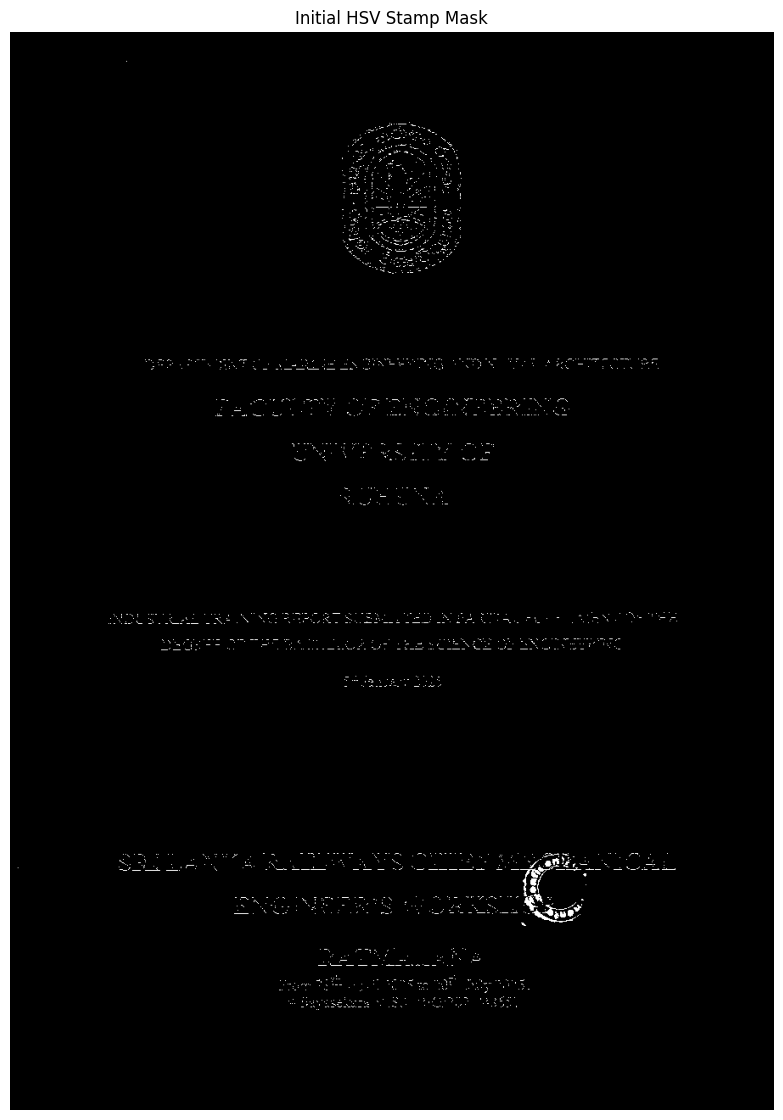

In [59]:
plt.figure(figsize=(10, 14))
plt.imshow(mask, cmap="gray")
plt.title("Initial HSV Stamp Mask")
plt.axis("off")
plt.show()

## 9. Morphological Closing — Fill Ink Gaps

**Operation:** Dilation followed by Erosion  
**Kernel:** Elliptical, 9 × 9 px

Applies closing (dilation → erosion) on the binary mask using a 9×9 elliptical kernel.

- **Dilation** expands white regions to bridge small gaps caused by uneven ink deposition
- **Erosion** shrinks them back to the original size — leaving the gaps filled without changing the overall stamp shape
- **Elliptical kernel** preserves the circular geometry of the stamp


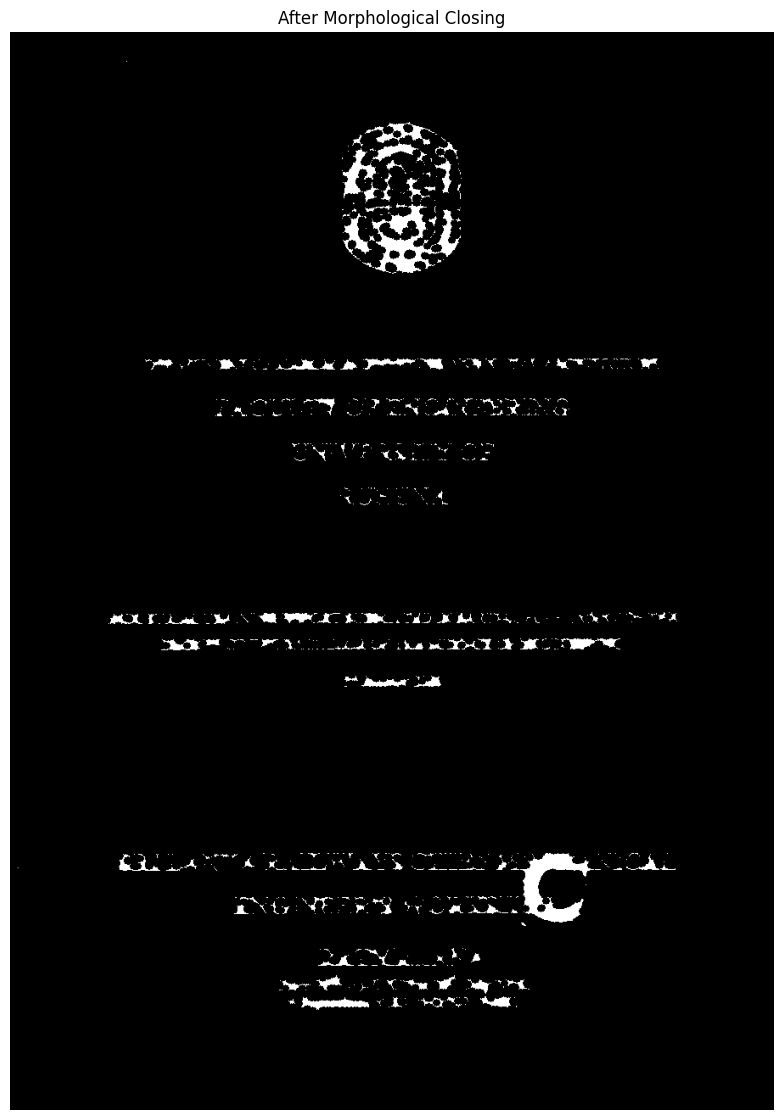

In [60]:
kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))

mask_closed = cv2.morphologyEx(
    mask,
    cv2.MORPH_CLOSE,
    kernel_close
)

plt.figure(figsize=(10, 14))
plt.imshow(mask_closed, cmap="gray")
plt.title("After Morphological Closing")
plt.axis("off")
plt.show()

## 10. Morphological Opening — Remove Text Noise

**Operation:** Erosion followed by Dilation  
**Kernel:** Elliptical, 5 × 5 px

Applies opening (erosion → dilation) on the closed mask using a 5×5 elliptical kernel.

- **Erosion** shrinks white regions first, removing any thin structures smaller than the kernel such as overlapping text strokes and fine noise that were not filtered by the colour threshold
- **Dilation** expands the remaining regions back to their original size — restoring the stamp shape while keeping the removed noise gone
- A **smaller 5×5 kernel** is used compared to closing (9×9) to avoid eroding the stamp ink itself


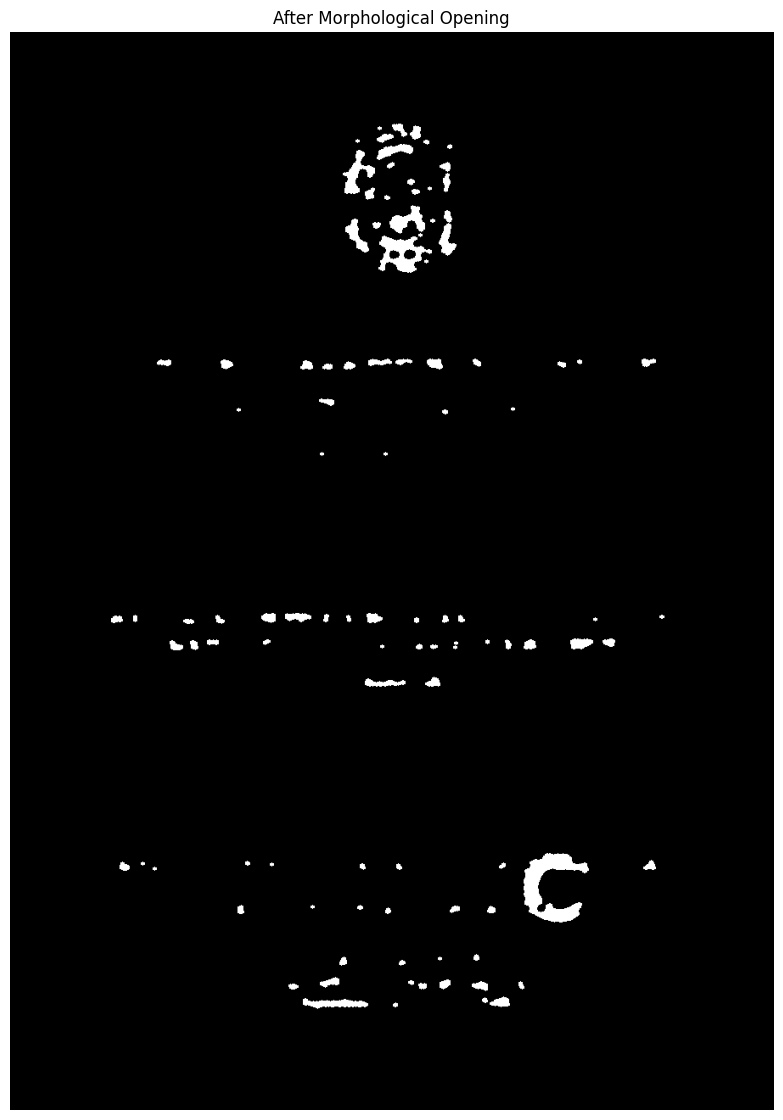

In [61]:
kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

mask_opened = cv2.morphologyEx(
    mask_closed,
    cv2.MORPH_OPEN,
    kernel_open
)

plt.figure(figsize=(10, 14))
plt.imshow(mask_opened, cmap="gray")
plt.title("After Morphological Opening")
plt.axis("off")
plt.show()

## Connected Component Filtering — Remove Remaining Noise

Runs connected component analysis on the opened mask and removes any remaining regions that are unlikely to be part of a stamp based on two conditions:

- **Area < 80 px²** — too small to be a stamp fragment, likely fine noise
- **Aspect ratio outside 0.5–2.0** — too elongated to be a circular stamp region, likely residual text strokes

Only compact, roughly circular regions are kept in `filtered_mask` and passed to the next stage.

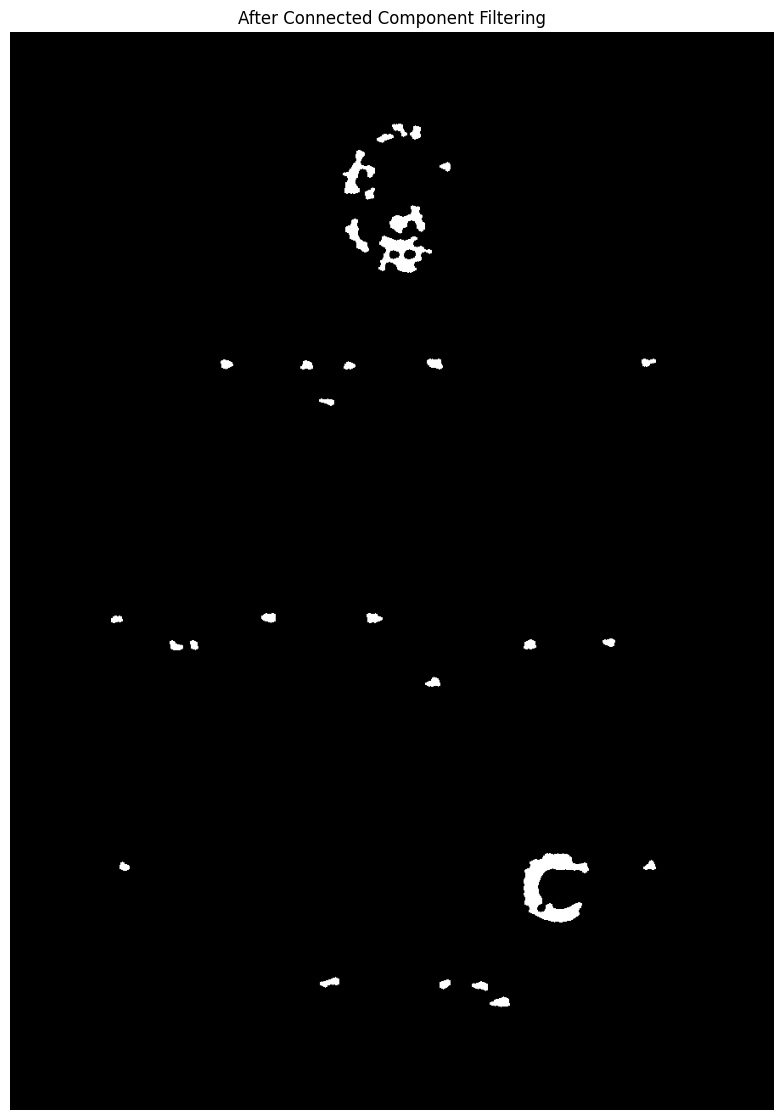

In [62]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_opened, connectivity=8)

filtered_mask = np.zeros_like(mask_opened)

for i in range(1, num_labels):  # skip background
    x, y, w, h, area = stats[i]

    if area < 80:
        continue

    aspect_ratio = w / h if h > 0 else 0

    # Keep compact/circular-ish regions, remove long text strokes
    if 0.5 <= aspect_ratio <= 2.0:
        filtered_mask[labels == i] = 255

plt.figure(figsize=(10, 14))
plt.imshow(filtered_mask, cmap="gray")
plt.title("After Connected Component Filtering")
plt.axis("off")
plt.show()

## 12. Final Comparison

Side-by-side display of:
1. Original image
2. Morphology output (`mask_opened`)
3. Component-filtered mask (`filtered_mask`)

`filtered_mask` is the output passed to the geometric localisation stage.


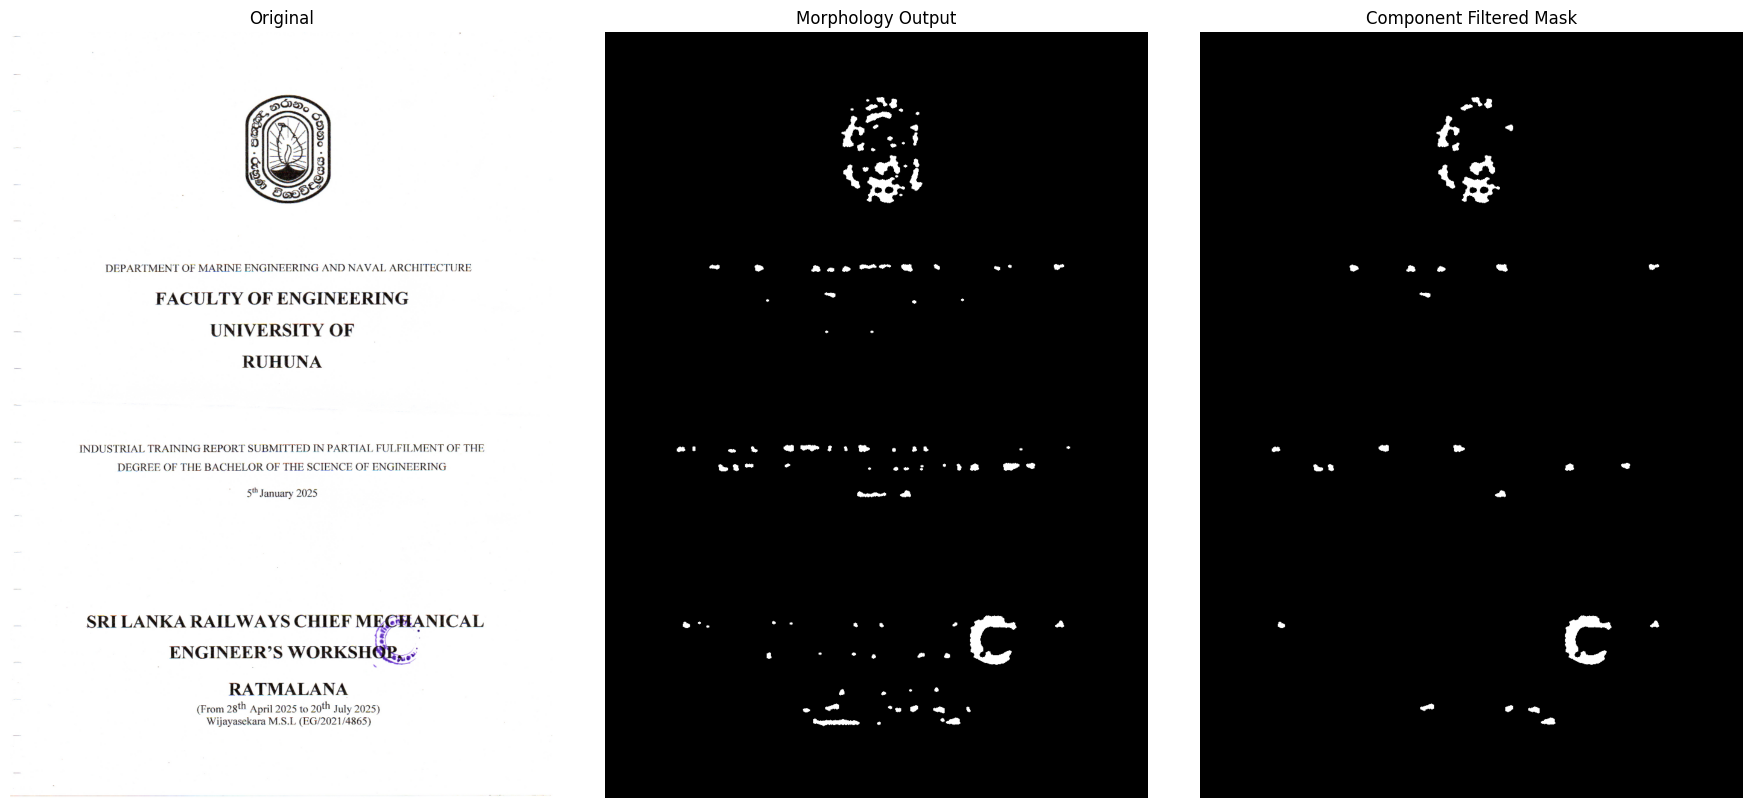

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

axes[0].imshow(image_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(mask_opened, cmap="gray")
axes[1].set_title("Morphology Output")
axes[1].axis("off")

axes[2].imshow(filtered_mask, cmap="gray")
axes[2].set_title("Component Filtered Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()